In [43]:
# Student Name: Amir Gharghabi
# Student ID: 810102217
# HW: 2
# Q: 8

In [92]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split


In [123]:
noisy_moons = datasets.make_moons(n_samples=500, noise=0.11)
Class1 = noisy_moons[0]
Class2 = noisy_moons[1]




In [136]:
# Assuming 'noisy_moons' is your dataset
X, y = datasets.make_moons(n_samples=500, noise=0.11)

# Split the dataset into two classes
Class1 = X[y == 0]
Class2 = X[y == 1]

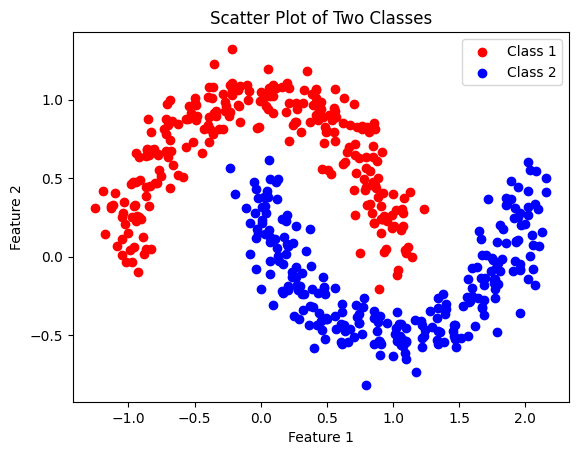

In [127]:
# Scatter plot for Class 1 (color='red')
plt.scatter(Class1[:, 0], Class1[:, 1], c='red', label='Class 1')

# Scatter plot for Class 2 (color='blue')
plt.scatter(Class2[:, 0], Class2[:, 1], c='blue', label='Class 2')

# Add labels and legend
plt.title('Scatter Plot of Two Classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

# Show the plot
plt.show()

In [129]:
# Function to calculate the mean
def calculate_mean(data):
    return sum(data) / len(data)

# Function to calculate the covariance matrix
def calculate_covariance_matrix(data, mean):
    n = len(data)
    if n <= 1:
        raise ValueError("Insufficient data to calculate covariance matrix")

    num_features = len(data[0])
    cov_matrix = np.zeros((num_features, num_features))

    for i in range(num_features):
        for j in range(num_features):
            cov_ij = sum((data[k][i] - mean[i]) * (data[k][j] - mean[j]) for k in range(n))
            cov_matrix[i][j] = cov_ij / (n - 1)

    return cov_matrix

# Function to calculate the multivariate normal PDF
def multivariate_normal_pdf(x, mean, cov_matrix):
    mahalanobis = np.dot(np.dot((x - mean).T, np.linalg.inv(cov_matrix)), (x - mean))
    pdf = (1 / (np.sqrt((2 * np.pi) ** len(mean) * np.linalg.det(cov_matrix)))) * np.exp(-0.5 * mahalanobis)
    return pdf


In [130]:
# Estimate parameters for each class
mean_Class1 = calculate_mean(Class1)
cov_Class1 = calculate_covariance_matrix(Class1, mean_Class1)

mean_Class2 = calculate_mean(Class2)
cov_Class2 = calculate_covariance_matrix(Class2, mean_Class2)

# Print the estimated parameters
print("Class 1 - Mean:\n", mean_Class1)
print("Class 1 - Covariance Matrix:\n", cov_Class1)

print("\nClass 2 - Mean:\n", mean_Class2)
print("Class 2 - Covariance Matrix:\n", cov_Class2)

Class 1 - Mean:
 [0.0027906 0.6261299]
Class 1 - Covariance Matrix:
 [[ 0.50093801 -0.00798078]
 [-0.00798078  0.1083887 ]]

Class 2 - Mean:
 [ 0.99827439 -0.12479807]
Class 2 - Covariance Matrix:
 [[ 0.49264681 -0.00168026]
 [-0.00168026  0.09907455]]


G:\UT\Term1\ML\Python\virtual_env\my_env\lib\site-packages\ipykernel_launcher.py:16: UserWarning: The following kwargs were not used by contour: 'label'
  
G:\UT\Term1\ML\Python\virtual_env\my_env\lib\site-packages\ipykernel_launcher.py:17: UserWarning: The following kwargs were not used by contour: 'label'
  app.launch_new_instance()


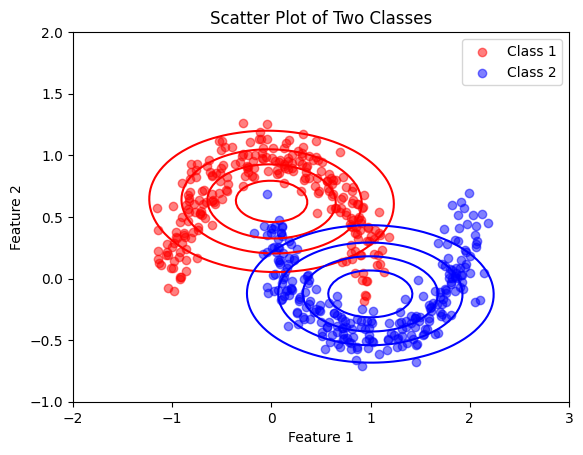

In [135]:
# Sample points for visualization
x_range = np.linspace(-2, 3, 100)
y_range = np.linspace(-1, 2, 100)
xx, yy = np.meshgrid(x_range, y_range)
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Calculate PDF values for each class
pdf_Class1 = np.array([multivariate_normal_pdf(point, mean_Class1, cov_Class1) for point in grid_points])
pdf_Class2 = np.array([multivariate_normal_pdf(point, mean_Class2, cov_Class2) for point in grid_points])

# Reshape for contour plot
pdf_Class1 = pdf_Class1.reshape(xx.shape)
pdf_Class2 = pdf_Class2.reshape(xx.shape)

# Plot the contours
plt.contour(xx, yy, pdf_Class1, levels=5, colors='red', label='Class 1')
plt.contour(xx, yy, pdf_Class2, levels=5, colors='blue', label='Class 2')

# Scatter plot for Class 1 (color='red')
plt.scatter(Class1[:, 0], Class1[:, 1], c='red', label='Class 1', alpha=0.5)
# Scatter plot for Class 2 (color='blue')
plt.scatter(Class2[:, 0], Class2[:, 1], c='blue', label='Class 2', alpha=0.5)

# Add labels and legend
plt.title('Scatter Plot of Two Classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

# Show the plot
plt.show()

In [139]:
from sklearn.mixture import GaussianMixture

# Function to calculate the mean
def calculate_mean(data):
    return np.sum(data, axis=0) / len(data)

# Function to calculate the covariance matrix
def calculate_covariance_matrix(data, mean):
    n = len(data)
    if n <= 1:
        raise ValueError("Insufficient data to calculate covariance matrix")

    num_features = len(data[0])
    cov_matrix = np.zeros((num_features, num_features))

    for i in range(num_features):
        for j in range(num_features):
            cov_ij = np.sum((data[k][i] - mean[i]) * (data[k][j] - mean[j]) for k in range(n))
            cov_matrix[i][j] = cov_ij / (n - 1)

    return cov_matrix

# Function to calculate the multivariate normal PDF
def multivariate_normal_pdf(x, mean, cov_matrix):
    mahalanobis = np.dot(np.dot((x - mean).T, np.linalg.inv(cov_matrix)), (x - mean))
    pdf = (1 / (np.sqrt((2 * np.pi) ** len(mean) * np.linalg.det(cov_matrix)))) * np.exp(-0.5 * mahalanobis)
    return pdf



In [140]:
# Fit a Gaussian Mixture Model with two components to the entire dataset
gmm = GaussianMixture(n_components=16, random_state=42)
gmm.fit(X)

# Create a meshgrid for visualization
x_range = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
y_range = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 100)
xx, yy = np.meshgrid(x_range, y_range)
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Calculate the estimated PDF values for each point on the grid
pdf_values = np.exp(gmm.score_samples(grid_points))
pdf_values = pdf_values.reshape(xx.shape)



G:\UT\Term1\ML\Python\virtual_env\my_env\lib\site-packages\ipykernel_launcher.py:6: UserWarning: The following kwargs were not used by contour: 'label'
  


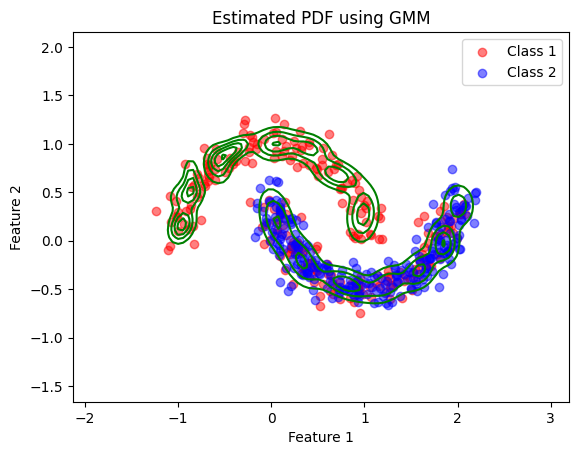

In [141]:
# Plot the dataset
plt.scatter(Class1[:, 0], Class1[:, 1], alpha=0.5, label='Class 1', c='red')
plt.scatter(Class2[:, 0], Class2[:, 1], alpha=0.5, label='Class 2', c='blue')

# Contour plot for the estimated PDF
plt.contour(xx, yy, pdf_values, levels=5, colors='green', label='Estimated PDF')

# Add labels and legend
plt.title('Estimated PDF using GMM')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

# Show the plot
plt.show()

In [ ]:
# End of Q6